In [21]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
tsadir='/work/scratch-pw2/licsar/mnergiz/inter_BOI_abs_test/116A_05207_252525/TS_GEOCml10'
framedir='/work/scratch-pw2/licsar/mnergiz/inter_BOI_abs_test/116A_05207_252525'
frame=os.path.basename(framedir)
cumfile=os.path.join(tsadir,'cum.h5')


In [22]:
# Load data
with h5.File(cumfile, 'r') as f:
    cum = f['cum'][()]
    imdates = f['imdates'][()].astype(str)
    tide = f['tide'][()]
    iono = f['iono'][()]

# Reference all to first epoch
cum = cum - cum[0]
tide = tide - tide[0]
iono = iono - iono[0]

# # Get daz correction (azimuth ionospheric delay)
# dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
# dazes['epoch'] = pd.to_datetime(dazes['epoch'])
# dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# # Interpolate daz to match imdates
# df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
# df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
# df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
# daz = df_daz['daz'].to_numpy()
# daz = daz - daz[0]  # Align to first epoch

# # Apply all corrections
# cum_abs = cum + daz[:, None, None] - tide - iono

In [4]:
cumaa = xr.load_dataset(cumfile)

In [5]:
cumaa

<xarray.Dataset>
Dimensions:                (phony_dim_0: 468, phony_dim_1: 387,
                            phony_dim_2: 343, phony_dim_3: 342)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/30)
    E.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    N.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    U.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    bperp                  (phony_dim_2) float64 -116.0 110.0 ... -127.0 -63.0
    coh_avg                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    corner_lat             float64 40.26
    ...                     ...
    cum_abs                (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide         (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide_noiono  (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    vel_abs                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide         (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide_noiono  (phony_dim_0, phony_dim_1) float32 nan nan ... nan

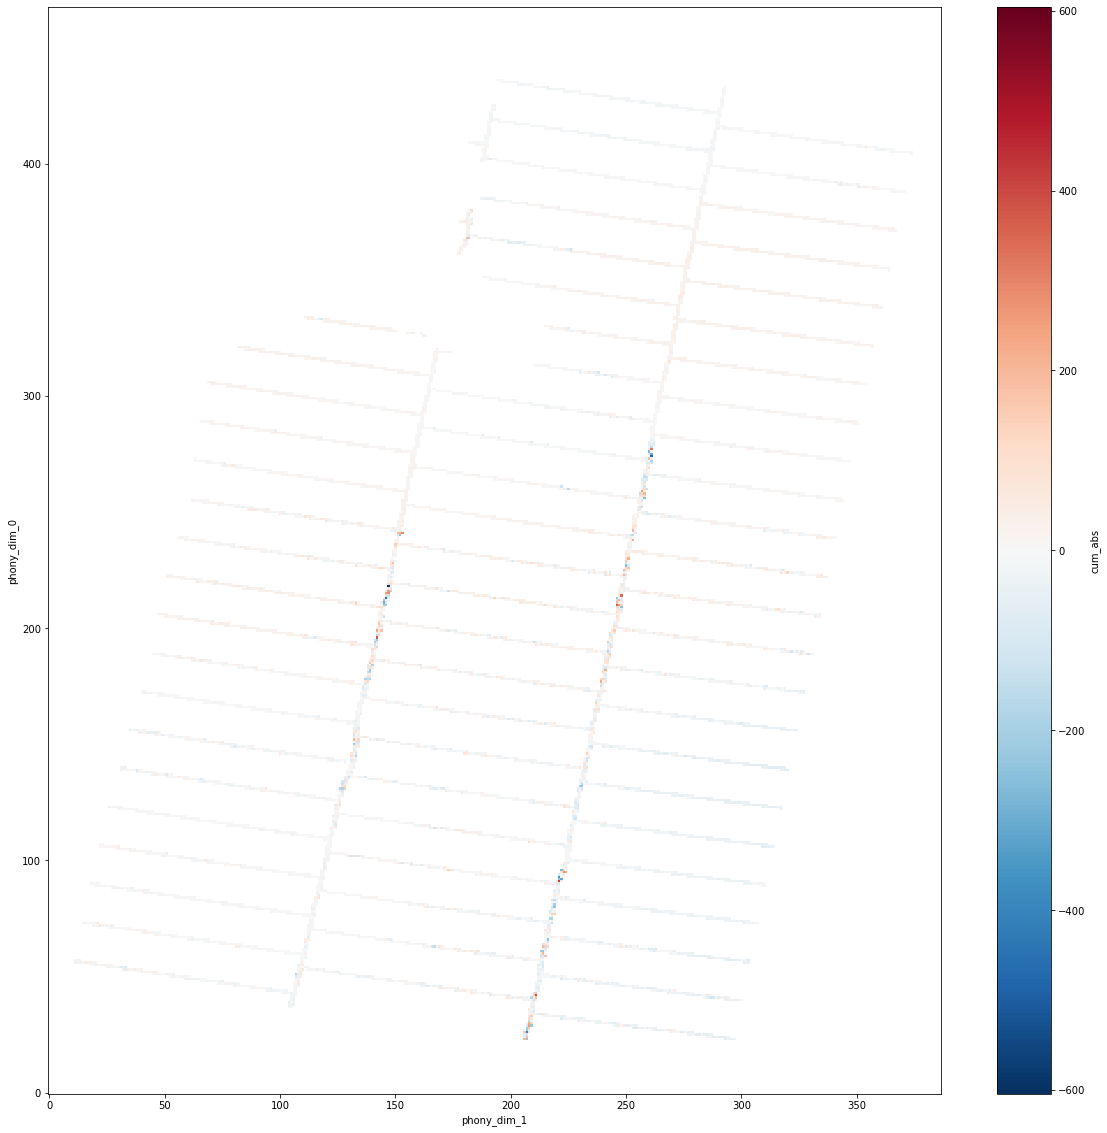

In [7]:
cumaa.cum_abs[1].plot(figsize=(20,20))

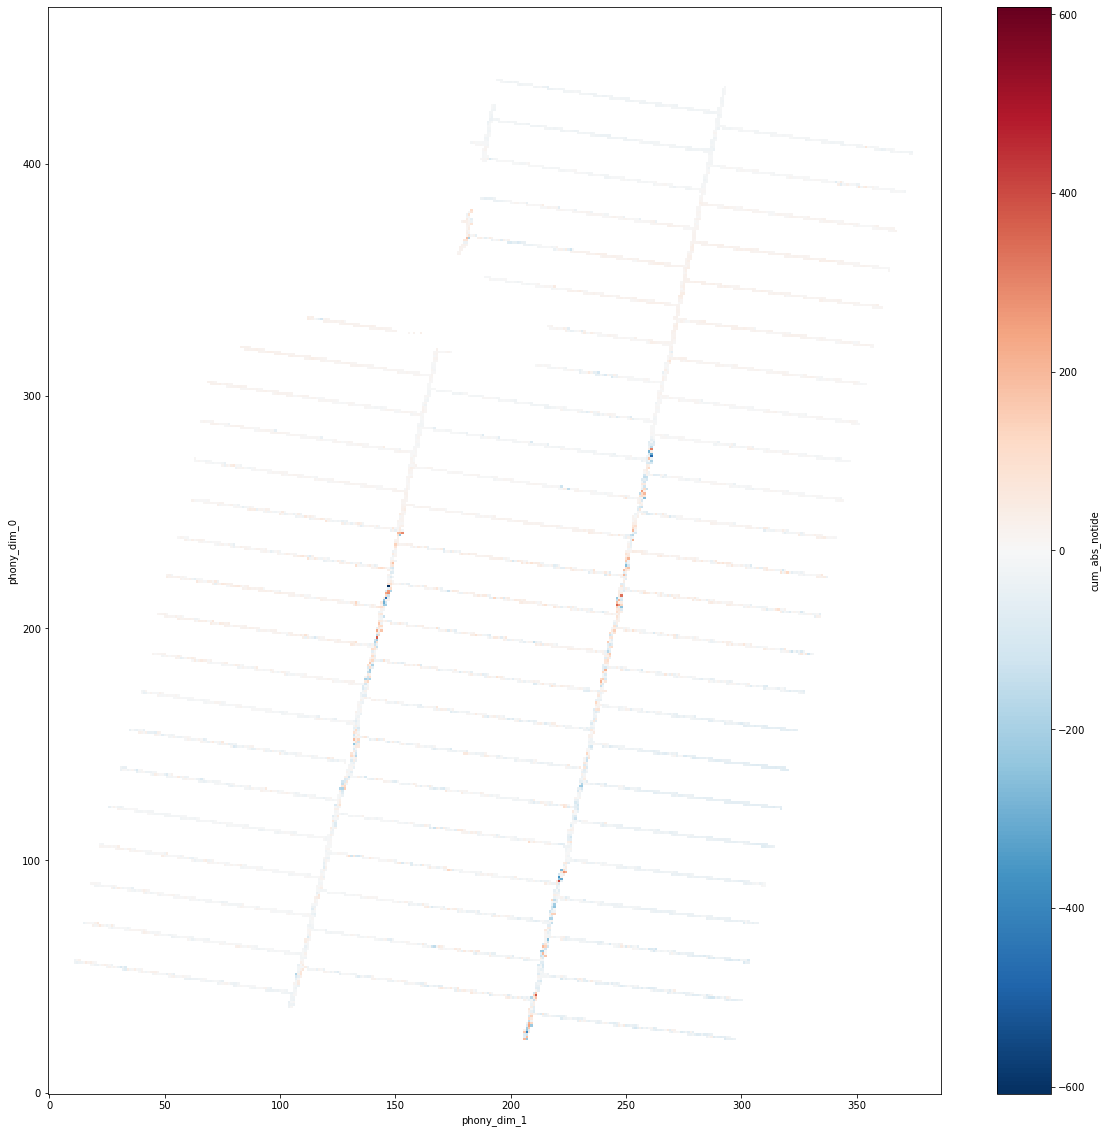

In [8]:
cumaa.cum_abs_notide[1].plot(figsize=(20,20))

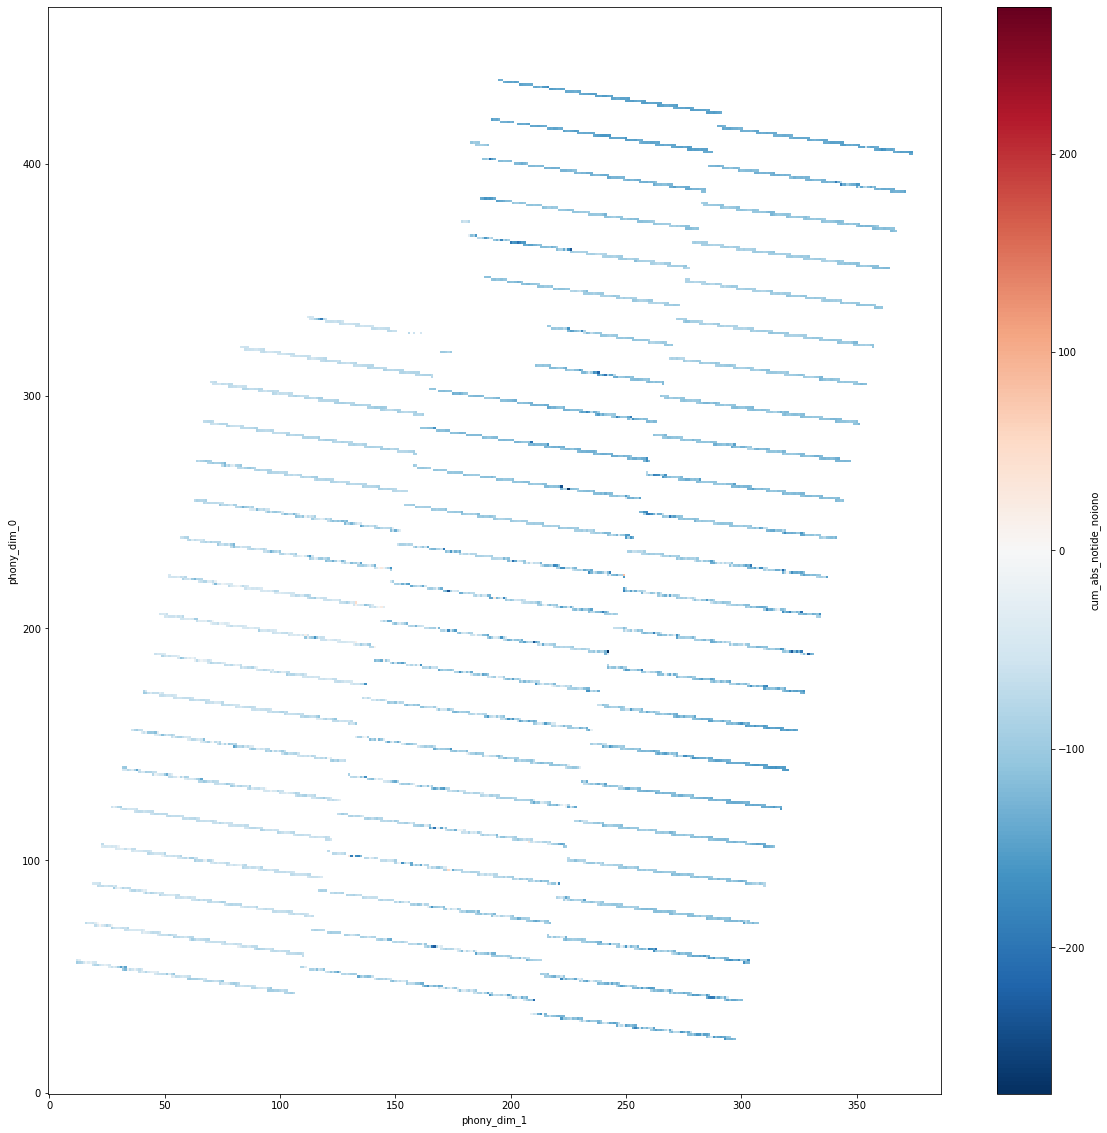

In [9]:
cumaa.cum_abs_notide_noiono[1].plot(figsize=(20,20))

In [17]:
trial_xdataset=cumaa.iono[3]

In [18]:
trial_xdataset

<xarray.DataArray 'iono' (phony_dim_0: 468, phony_dim_1: 387)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Dimensions without coordinates: phony_dim_0, phony_dim_1

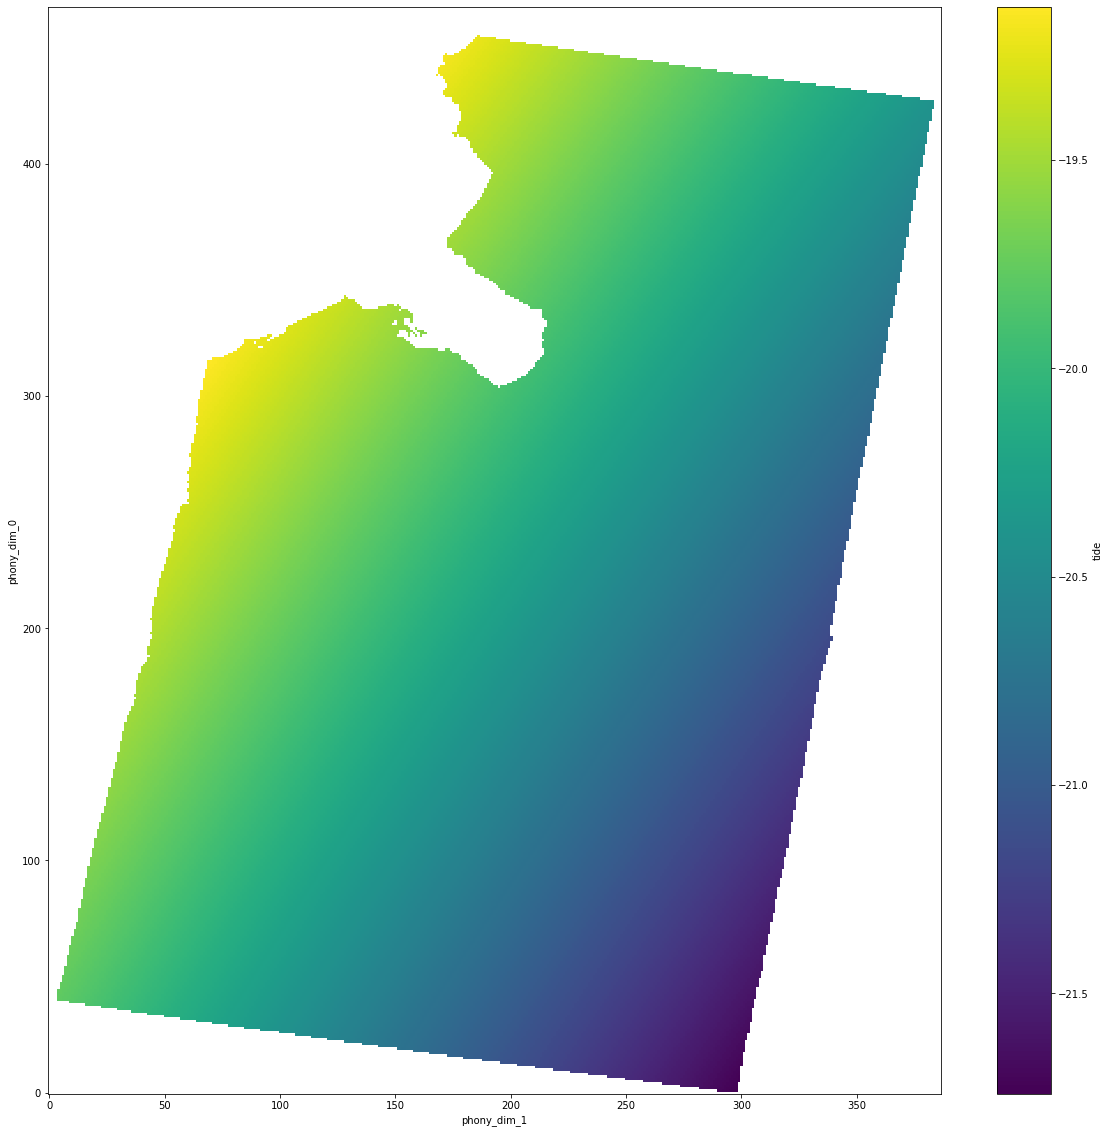

In [15]:
cumaa.tide[3].plot(figsize=(20,20))

In [19]:
cumaa

<xarray.Dataset>
Dimensions:                (phony_dim_0: 468, phony_dim_1: 387,
                            phony_dim_2: 26, phony_dim_3: 25)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/27)
    E.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    N.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    U.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    bperp                  (phony_dim_2) float64 -96.0 94.0 -32.0 ... -28.0 9.0
    coh_avg                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    corner_lat             float64 39.97
    ...                     ...
    vintercept             (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    tide                   (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    iono                   (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs                (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide         (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide_noiono  (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...

Failed to process 116A_04978_131311: tuple index out of range


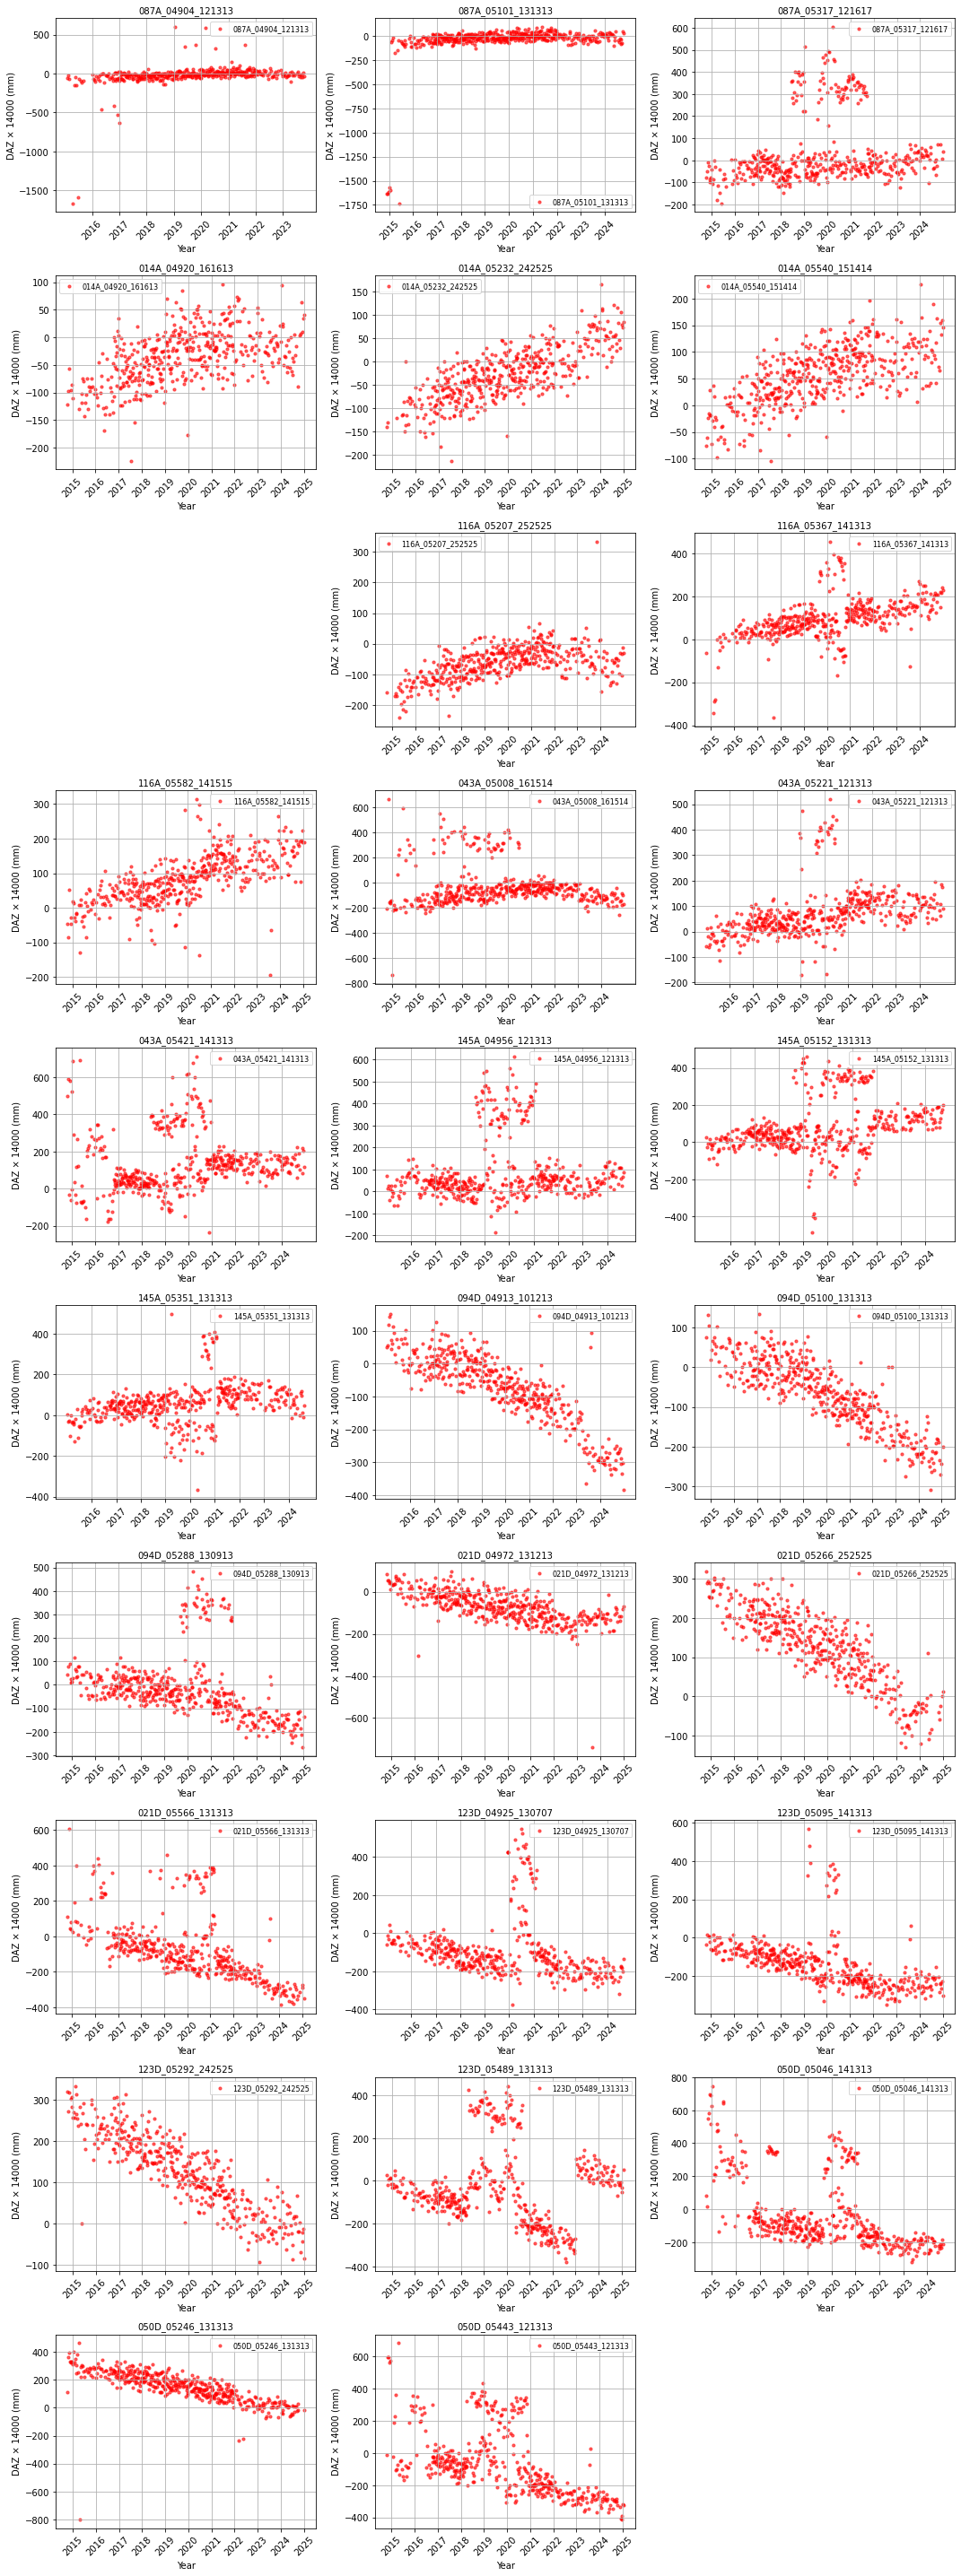

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt



# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
ncols = 3  # Number of plots per row
nrows = (n + ncols - 1) // ncols  # Auto calculate rows
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=False)
axs = axs.flatten()

# Loop through each frame and plot
for i, frame in enumerate(frames_TR):
    try:
        # Load data
        df = dl.extract2txt_esds_frame(frame)
        df['epoch'] = pd.to_datetime(df['epoch'], format='%Y%m%d')
        df = df.sort_values(by='epoch')

        # Plot
        axs[i].scatter(df['epoch'], df['daz_total_wrt_orbits'] * 14000, color='red', alpha=0.6, s=10, label=frame)
        axs[i].set_title(frame, fontsize=10)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('DAZ × 14000 (mm)')
        axs[i].legend(fontsize=8)
        axs[i].grid(True)
        xticks = pd.date_range(start=df['epoch'].min(), end=df['epoch'].max(), freq='YS')
        axs[i].set_xticks(xticks)
        axs[i].set_xticklabels(xticks.year, rotation=45)
    except Exception as e:
        print(f"Failed to process {frame}: {e}")
        axs[i].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


Failed to process 116A_04978_131311: tuple index out of range


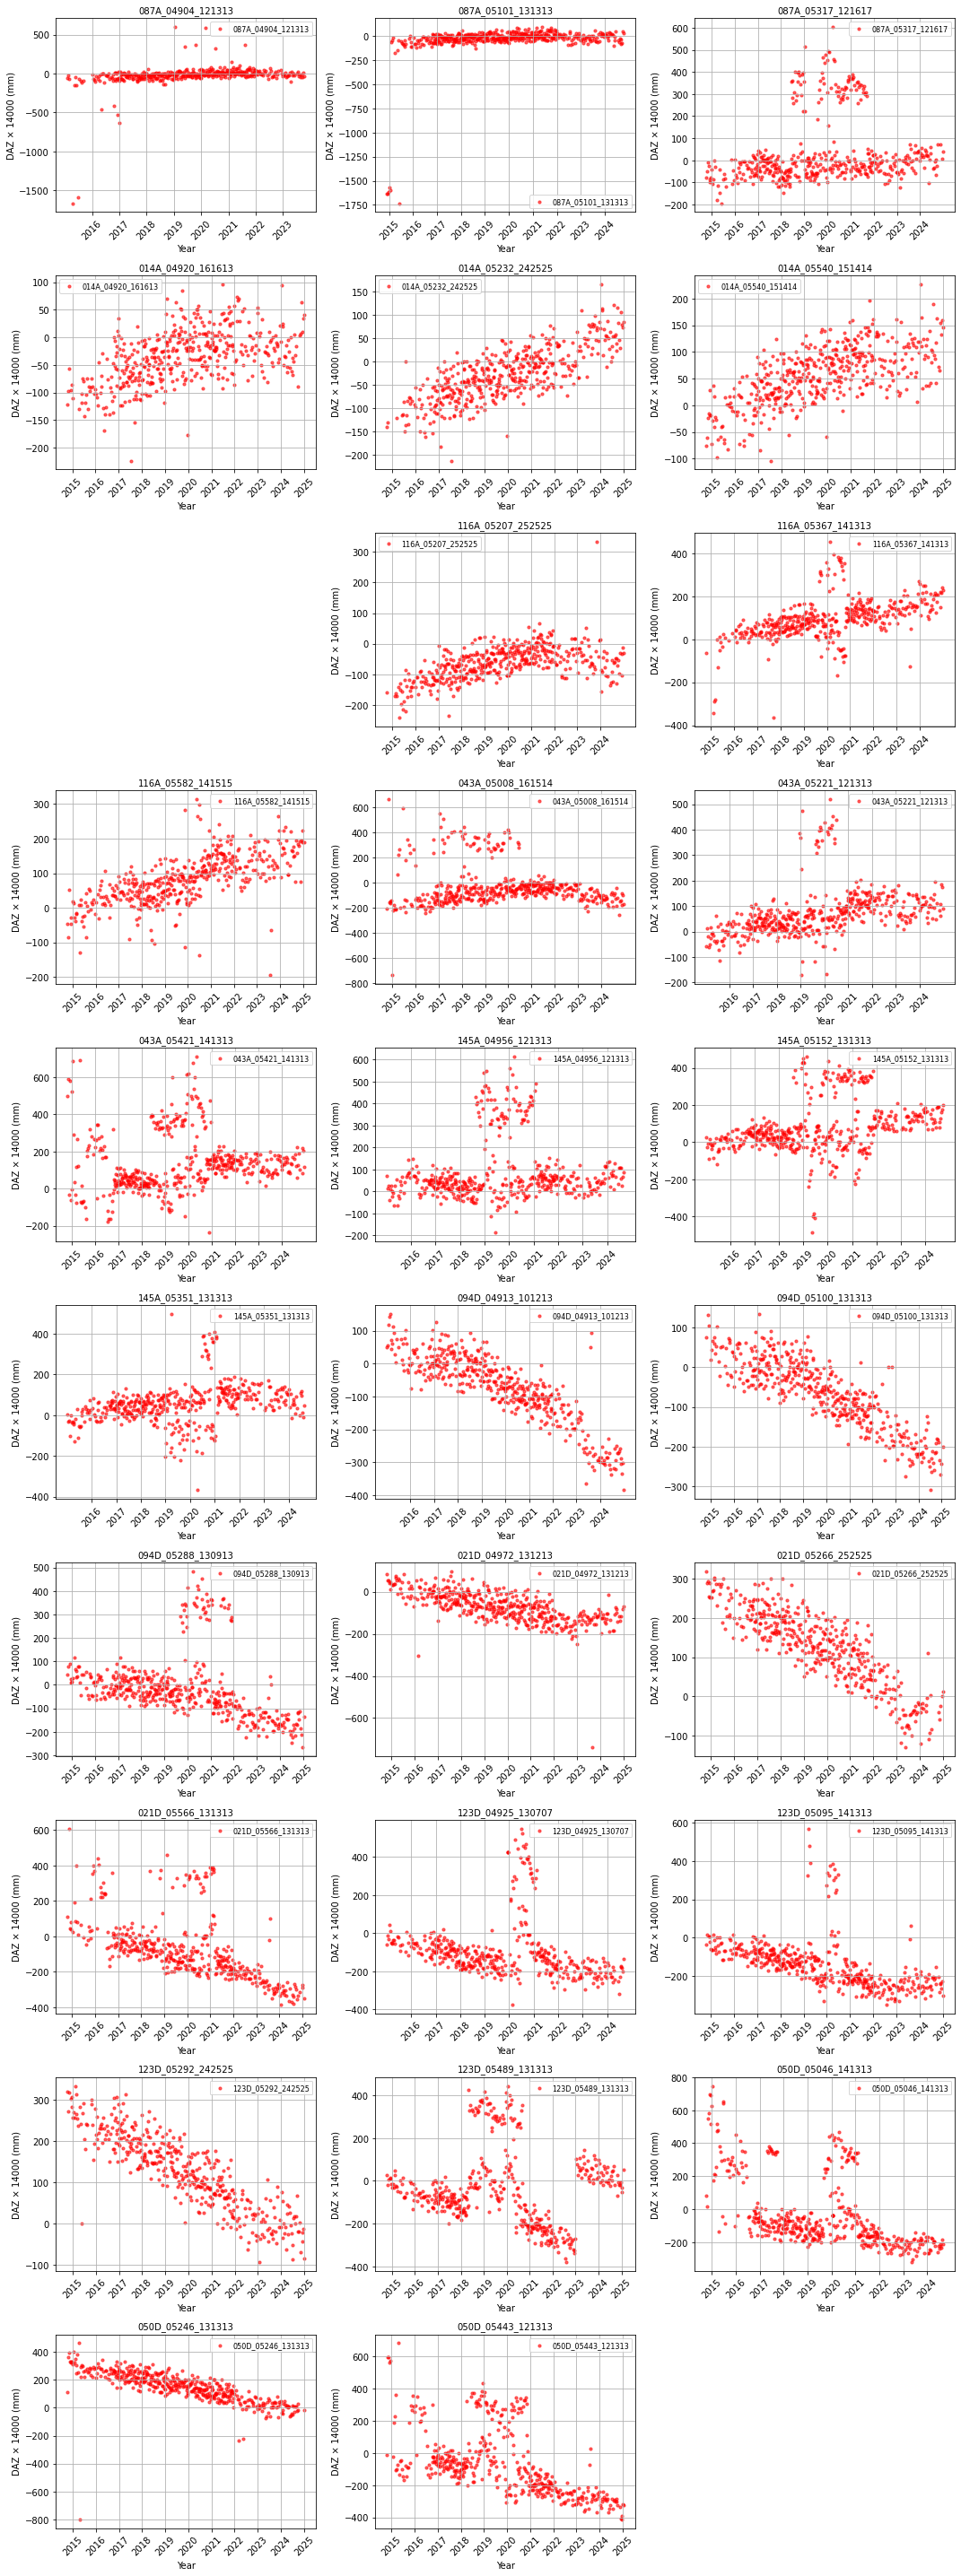

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import daz_lib_licsar as dl
# Assuming you have a custom module 'dl' that provides your data


# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
ncols = 3  # Number of plots per row
nrows = (n + ncols - 1) // ncols  # Auto calculate rows
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=False)
axs = axs.flatten()

# Loop through each frame and plot
for i, frame in enumerate(frames_TR):
    try:
        # Load data
        df = dl.get_daz_frame(frame)[['epoch', 'daz']]
        df['epoch'] = pd.to_datetime(df['epoch'], format='%Y-%m-%d')
        df = df.sort_values(by='epoch')

        # Plot
        axs[i].scatter(df['epoch'], df['daz']*14000, color='red', alpha=0.6, s=10, label=frame)
        axs[i].set_title(frame, fontsize=10)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('DAZ × 14000 (mm)')
        axs[i].legend(fontsize=8)
        axs[i].grid(True)
        xticks = pd.date_range(start=df['epoch'].min(), end=df['epoch'].max(), freq='YS')
        axs[i].set_xticks(xticks)
        axs[i].set_xticklabels(xticks.year, rotation=45)
    except Exception as e:
        print(f"Failed to process {frame}: {e}")
        axs[i].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


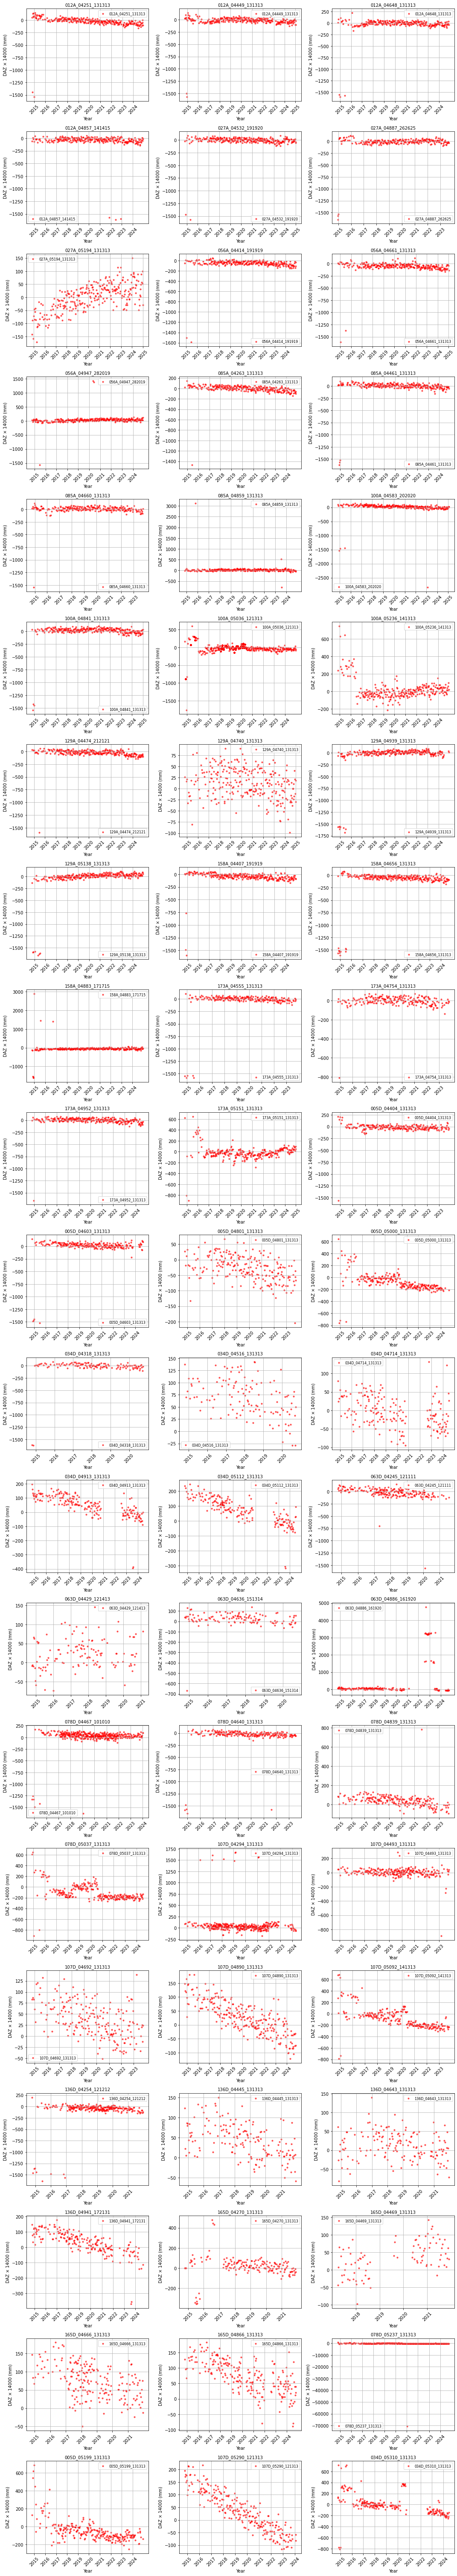

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import daz_lib_licsar as dl
# Assuming you have a custom module 'dl' that provides your data


# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TienShan')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
ncols = 3  # Number of plots per row
nrows = (n + ncols - 1) // ncols  # Auto calculate rows
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=False)
axs = axs.flatten()

# Loop through each frame and plot
for i, frame in enumerate(frames_TR):
    try:
        # Load data
        df = dl.get_daz_frame(frame)[['epoch', 'daz']]
        df['epoch'] = pd.to_datetime(df['epoch'], format='%Y-%m-%d')
        df = df.sort_values(by='epoch')

        # Plot
        axs[i].scatter(df['epoch'], df['daz']*14000, color='red', alpha=0.6, s=10, label=frame)
        axs[i].set_title(frame, fontsize=10)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('DAZ × 14000 (mm)')
        axs[i].legend(fontsize=8)
        axs[i].grid(True)
        xticks = pd.date_range(start=df['epoch'].min(), end=df['epoch'].max(), freq='YS')
        axs[i].set_xticks(xticks)
        axs[i].set_xticklabels(xticks.year, rotation=45)
    except Exception as e:
        print(f"Failed to process {frame}: {e}")
        axs[i].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()
